# NB04: Multivariate Prediction Model

Build XGBoost model predicting metal_score_norm from phenotype features.

- XGBoost (handles missing values natively)
- 5-fold CV with phylogenetic blocking (no species from same genus in train+test)
- SHAP feature importance
- Baseline comparisons: taxonomy-only, gene count only, full model

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

MAIN_REPO = '/home/psdehal/pangenome_science/BERIL-research-observatory'
PROJ = os.path.join(MAIN_REPO, 'projects', 'bacdive_phenotype_metal_tolerance')
DATA_OUT = os.path.join(PROJ, 'data')
FIG_OUT = os.path.join(PROJ, 'figures')

feat = pd.read_csv(os.path.join(DATA_OUT, 'species_phenotype_matrix.csv'))
print(f'Feature matrix: {len(feat)} species')

Feature matrix: 5647 species


## 1. Prepare feature sets

In [2]:
# Define feature sets for baseline comparisons
phenotype_cols = [
    'gram_positive_binary', 'motile_binary',
    'catalase_pos_binary', 'oxidase_pos_binary', 'urease_pos_binary',
    'nitrate_pos_binary', 'h2s_pos_binary', 'acetate_pos_binary',
    'metabolite_frac_pos_mean', 'enzyme_frac_pos_mean',
]

# Encode oxygen tolerance as dummy variables
if 'oxygen_simple_majority' in feat.columns:
    oxy_dummies = pd.get_dummies(feat['oxygen_simple_majority'], prefix='oxygen', dummy_na=False)
    feat = pd.concat([feat, oxy_dummies], axis=1)
    oxy_cols = [c for c in oxy_dummies.columns]
    phenotype_cols.extend(oxy_cols)

# Taxonomy features (encode as category codes for tree-based model)
for tax_col in ['bacdive_phylum', 'bacdive_class', 'bacdive_order']:
    if tax_col in feat.columns:
        feat[f'{tax_col}_code'] = feat[tax_col].astype('category').cat.codes
        # Replace -1 (NaN) with NaN for XGBoost missing value handling
        feat.loc[feat[f'{tax_col}_code'] == -1, f'{tax_col}_code'] = np.nan

taxonomy_cols = [c for c in feat.columns if c.endswith('_code')]
gene_count_cols = ['n_metal_clusters']

target = 'metal_score_norm'

# Require at least 5 non-null phenotype features per species
feat['n_pheno_features'] = feat[phenotype_cols].notna().sum(axis=1)
analysis_df = feat[feat['n_pheno_features'] >= 5].copy()
print(f'Species with ≥5 phenotype features: {len(analysis_df)}')

# Extract genus for phylogenetic blocking
analysis_df['genus'] = analysis_df['species'].str.extract(r's__(.+?)_')[0]
print(f'Unique genera: {analysis_df["genus"].nunique()}')

Species with ≥5 phenotype features: 3994
Unique genera: 1154


## 2. Define model configurations

In [3]:
model_configs = {
    'Taxonomy only': taxonomy_cols,
    'Gene count only': gene_count_cols,
    'Phenotype only': phenotype_cols,
    'Taxonomy + Phenotype': taxonomy_cols + phenotype_cols,
    'Full (Tax + Pheno + Gene count)': taxonomy_cols + phenotype_cols + gene_count_cols,
}

for name, cols in model_configs.items():
    available = [c for c in cols if c in analysis_df.columns]
    print(f'{name}: {len(available)} features')

Taxonomy only: 3 features
Gene count only: 1 features
Phenotype only: 13 features
Taxonomy + Phenotype: 16 features
Full (Tax + Pheno + Gene count): 17 features


## 3. Cross-validation with phylogenetic blocking

In [4]:
def run_cv(df, feature_cols, target_col, group_col, n_splits=5):
    """Run GroupKFold CV with XGBoost, blocking by genus."""
    available_cols = [c for c in feature_cols if c in df.columns]
    
    # Drop rows with missing target
    valid = df[df[target_col].notna()].copy()
    if len(valid) < 50:
        return None
    
    X = valid[available_cols].values
    y = valid[target_col].values
    groups = valid[group_col].values
    
    gkf = GroupKFold(n_splits=n_splits)
    y_pred_all = np.full(len(y), np.nan)
    
    for train_idx, test_idx in gkf.split(X, y, groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = xgb.XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0,
            tree_method='hist',  # handles NaN natively
        )
        model.fit(X_train, y_train)
        y_pred_all[test_idx] = model.predict(X_test)
    
    valid_mask = ~np.isnan(y_pred_all)
    r2 = r2_score(y[valid_mask], y_pred_all[valid_mask])
    rmse = np.sqrt(mean_squared_error(y[valid_mask], y_pred_all[valid_mask]))
    
    return {'r2': r2, 'rmse': rmse, 'n': int(valid_mask.sum()), 'features': available_cols}

# Run all model configurations
cv_results = {}
for name, cols in model_configs.items():
    result = run_cv(analysis_df, cols, target, 'genus')
    if result:
        cv_results[name] = result
        print(f'{name:40s}: R²={result["r2"]:.4f}, RMSE={result["rmse"]:.4f}, n={result["n"]}')
    else:
        print(f'{name:40s}: Insufficient data')

Taxonomy only                           : R²=0.3538, RMSE=0.0377, n=3994


Gene count only                         : R²=0.0630, RMSE=0.0453, n=3994


Phenotype only                          : R²=0.1631, RMSE=0.0428, n=3994


Taxonomy + Phenotype                    : R²=0.3451, RMSE=0.0379, n=3994


Full (Tax + Pheno + Gene count)         : R²=0.6327, RMSE=0.0284, n=3994


## 4. SHAP feature importance

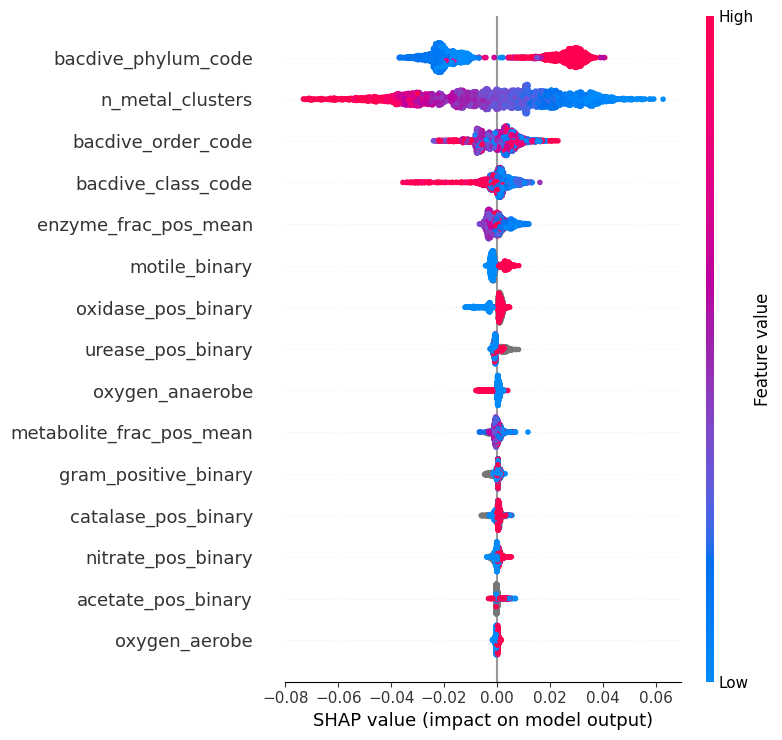

Saved: figures/shap_summary.png


In [5]:
# Train full model for SHAP analysis
full_cols = [c for c in (taxonomy_cols + phenotype_cols + gene_count_cols) if c in analysis_df.columns]
valid = analysis_df[analysis_df[target].notna()].copy()

X_full = valid[full_cols]
y_full = valid[target].values

full_model = xgb.XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0, tree_method='hist',
)
full_model.fit(X_full, y_full)

# SHAP values
explainer = shap.TreeExplainer(full_model)
shap_values = explainer.shap_values(X_full)

# SHAP summary plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_full, feature_names=full_cols, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/shap_summary.png')

## 5. Model comparison visualization

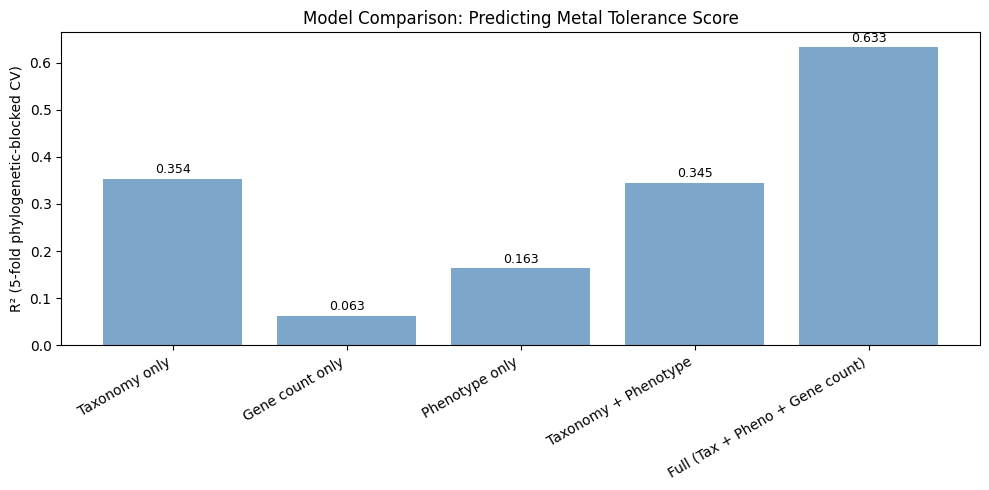

Saved: figures/model_comparison.png

=== Delta R² Analysis ===
Adding phenotype to taxonomy: delta R² = -0.0087
Adding tax+phenotype to gene count: delta R² = +0.5697


In [6]:
# Bar chart of R² across models
if cv_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    names = list(cv_results.keys())
    r2_vals = [cv_results[n]['r2'] for n in names]
    
    bars = ax.bar(range(len(names)), r2_vals, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_ylabel('R² (5-fold phylogenetic-blocked CV)')
    ax.set_title('Model Comparison: Predicting Metal Tolerance Score')
    
    # Add value labels
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_OUT, 'model_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: figures/model_comparison.png')

    # Delta R² analysis
    print('\n=== Delta R² Analysis ===')
    if 'Taxonomy only' in cv_results and 'Taxonomy + Phenotype' in cv_results:
        delta = cv_results['Taxonomy + Phenotype']['r2'] - cv_results['Taxonomy only']['r2']
        print(f'Adding phenotype to taxonomy: delta R² = {delta:+.4f}')
    if 'Gene count only' in cv_results and 'Full (Tax + Pheno + Gene count)' in cv_results:
        delta = cv_results['Full (Tax + Pheno + Gene count)']['r2'] - cv_results['Gene count only']['r2']
        print(f'Adding tax+phenotype to gene count: delta R² = {delta:+.4f}')

In [7]:
# Save results
results_df = pd.DataFrame([
    {'Model': name, 'R2': r['r2'], 'RMSE': r['rmse'], 'n': r['n'], 'n_features': len(r['features'])}
    for name, r in cv_results.items()
])
results_df.to_csv(os.path.join(DATA_OUT, 'model_comparison.csv'), index=False)
print(results_df.to_string(index=False))
print(f'\nSaved: data/model_comparison.csv')

                          Model       R2     RMSE    n  n_features
                  Taxonomy only 0.353812 0.037650 3994           3
                Gene count only 0.063018 0.045337 3994           1
                 Phenotype only 0.163146 0.042846 3994          13
           Taxonomy + Phenotype 0.345076 0.037904 3994          16
Full (Tax + Pheno + Gene count) 0.632715 0.028385 3994          17

Saved: data/model_comparison.csv
